
Early stopping occurred at epoch 199 with best_epoch = 179 and best_valid_rmse = 25.56943
Train R²: 0.9856
Test  R²: 0.9880
R² Gap (Train - Test): -0.0024
Train RMSE: 26.9287
Test  RMSE: 25.5694
RMSE Gap (Test - Train): -1.3592


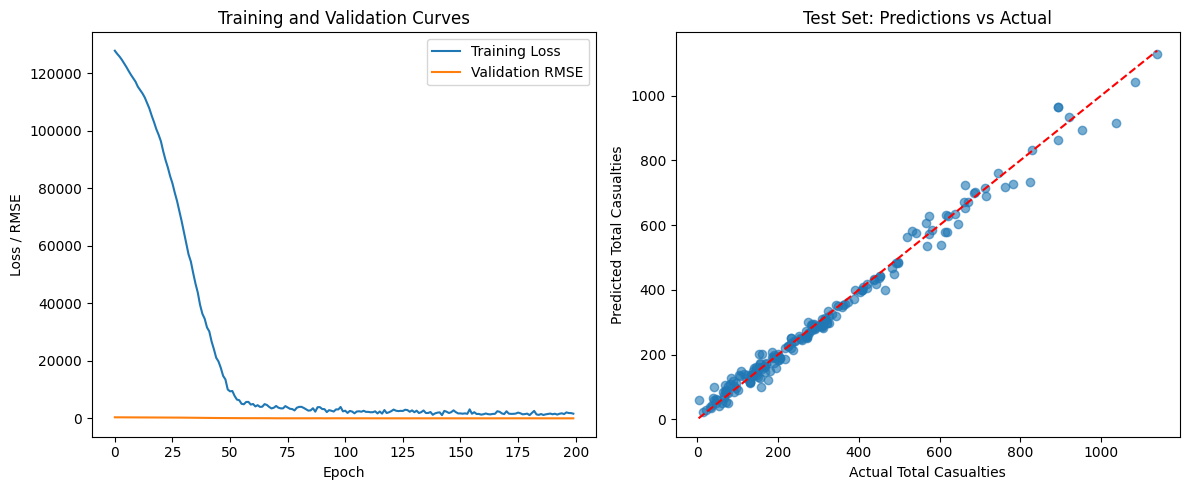

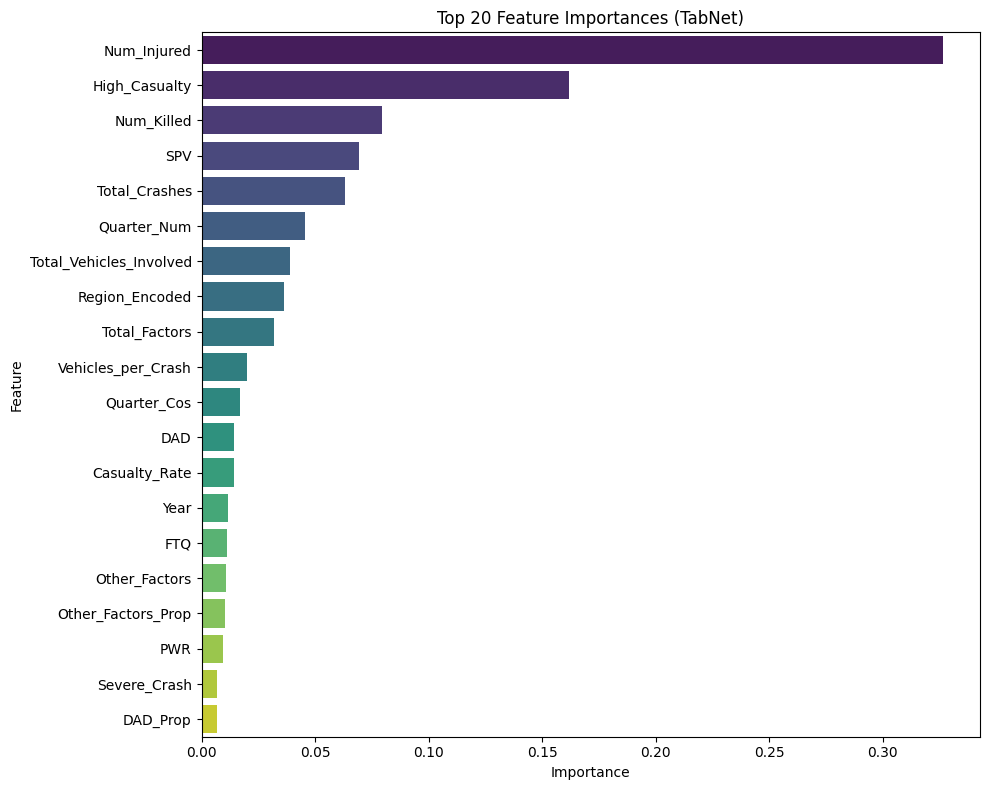

In [3]:
import subprocess
import sys
try:
    from pytorch_tabnet.tab_model import TabNetRegressor
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pytorch_tabnet"])
    from pytorch_tabnet.tab_model import TabNetRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import torch
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
drop_cols = ['Quarter', 'State', 'Quarter_Date', 'State_Encoded']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
state_dummies = [c for c in df.columns if c.startswith('State_')]
df.drop(columns=state_dummies, inplace=True)
df = df.select_dtypes(include=[np.number])
df.dropna(inplace=True)
target = 'Total_Casualties'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_2d = y_train.values.reshape(-1, 1)
y_test_2d = y_test.values.reshape(-1, 1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tabnet = TabNetRegressor(
    n_d=64, n_a=64, n_steps=5, gamma=1.5,
    lambda_sparse=1e-4, optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type='sparsemax', device_name=device,
    verbose=0, seed=42
)
tabnet.fit(
    X_train_scaled, y_train_2d,
    eval_set=[(X_test_scaled, y_test_2d)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=200, patience=20,
    batch_size=128, virtual_batch_size=64,
    num_workers=0, drop_last=False
)
train_pred = tabnet.predict(X_train_scaled).flatten()
test_pred = tabnet.predict(X_test_scaled).flatten()
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
history = tabnet.history['loss']
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history, label='Training Loss')
plt.plot(tabnet.history['valid_rmse'], label='Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('Loss / RMSE')
plt.title('Training and Validation Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('Test Set: Predictions vs Actual')
plt.tight_layout()
plt.savefig('tabnet_results.png', dpi=150)
plt.show()
feature_importances = tabnet.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (TabNet)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()